In [47]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

In [48]:
data = pd.read_csv("heart.csv")
print(data.head())
print(data.shape)

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  
(303, 14)


In [49]:
X= data.drop("target", axis=1)
y = data["target"]

In [50]:
X_train, X_test,y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

In [51]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [52]:
model_sgd = MLPClassifier(
    hidden_layer_sizes=(10,10),
    activation="relu",
    solver="sgd",
    learning_rate_init=0.01,
    max_iter=1200,
    random_state=42
)

In [53]:
model_sgd.fit(X_train, y_train)
y_pred_sgd = model_sgd.predict(X_test)
accuracy_sgd = accuracy_score(y_test, y_pred_sgd)

In [54]:
model_adam = MLPClassifier(
    hidden_layer_sizes=(10,10),
    activation="relu",
    solver="adam",
    learning_rate_init=0.01,
    max_iter=1200,
    random_state=42
)

In [55]:
model_adam.fit(X_train, y_train)
y_pred_adam = model_adam.predict(X_test)
accuracy_adam = accuracy_score(y_test, y_pred_adam)

In [56]:
model_momentum = MLPClassifier(
    hidden_layer_sizes=(10,10),
    activation="relu",
    solver="momentum",
    learning_rate_init=0.01,
    max_iter=1200,
    random_state=42
)

In [ ]:
model_momentum.fit(X_train, y_train)
y_pred_momentum = model_momentum.predict(X_test)
accuracy_momentum = accuracy_score(y_test, y_pred_momentum)

In [60]:
model_rmsprop = MLPClassifier(
    hidden_layer_sizes=(10,10),
    activation="relu",
    solver="rmsprop",
    learning_rate_init=0.01,
    max_iter=1200,
    random_state=42
)

In [ ]:
model_rmsprop.fit(X_train, y_train)
y_pred_rmsprop = model_rmsprop.predict(X_test)
accuracy_rmsprop = accuracy_score(y_test, y_pred_rmsprop)

In [ ]:
print("\nPerformance Comparison")
print("--------------------------------------")
print("SGD Accuracy :", round(accuracy_sgd,2))
print("Adam Accuracy :", round(accuracy_adam,2))
print("Momentum Accuracy :", round(accuracy_momentum,2))
print("RMSProp Accuracy :", round(accuracy_rmsprop,2))


Performance Comparison
--------------------------------------
SGD Accuracy : 0.74
Adam Accuracy : 0.7


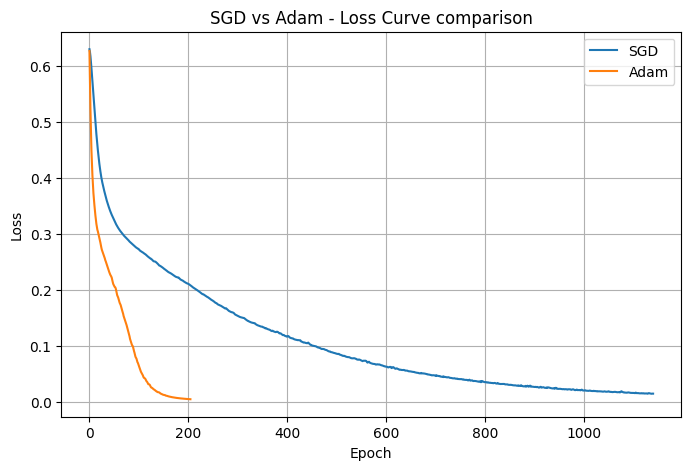

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(model_sgd.loss_curve_, label="SGD")
plt.plot(model_adam.loss_curve_, label="Adam")
plt.plot(model_momentum.loss_curve_, label="Momentum")
plt.plot(model_rmsprop.loss_curve_, label="RMSProp")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SGD vs Adam - Loss Curve comparison")
plt.legend()
plt.grid()
plt.show() 